In [1]:
# H2 Cone Search
# This notebook is dedicated to develop the cone_search and detector_search function in EPHESSOS
import ephessos as ep

In [11]:
from astropy.time import Time
import astropy.units as u

now = Time.now()
mjd = now.mjd # Time((mjd_end - mjd_start)/2., format="mjd")
mjd_start=now - 1200*u.s 
mjd_end= now - 600*u.s # 61042.01

cone_search = ep.core.cone_search(ra=230.028, dec=-11.774, mjd=mjd, search_radius=5*60, observatory=273, verbose=True)
ephessos_df = ep.core.ephessos(sso_search=cone_search, mjd_start=mjd_start, mjd_end=mjd_end, step_size="1min")

Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719
   name    ...
---------- ...
2017 SO297 ...
2017 QS101 ...
 2021 CX36 ...


100%|██████████| 3/3 [00:00<00:00,  3.94it/s]


In [13]:
mjd

np.float64(61158.99010249352)

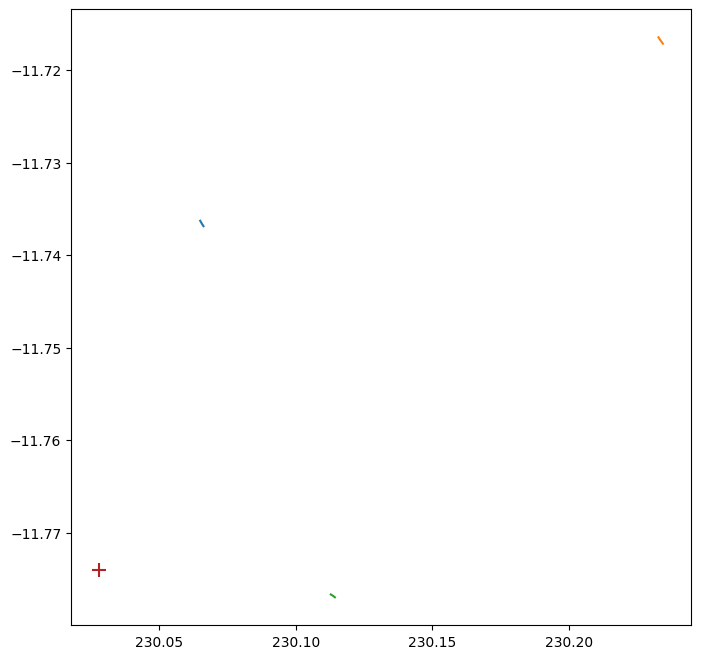

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))

for i in range(len(ephessos_df)):
    ax.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"])

ax.scatter(230.028, -11.774, marker="+", s=100, color="firebrick")

In [9]:
cone_search["Epoch"]

0    K25BL
0    K25BL
Name: Epoch, dtype: str

In [ ]:
if True: 
    from tqdm import tqdm
    ephessos_df_list = [] 
    for i in tqdm(range(len(cone_search))):
        # print(cone_search.iloc[i])
        designation = cone_search.iloc[i]['Designation']
        epoch = cone_search.iloc[i]['Epoch']
        eccentricity = cone_search.iloc[i]['Eccentricity']
        node = cone_search.iloc[i]['Node']
        arg_perihelion = cone_search.iloc[i]['Arg_Perihelion']
        inclination = cone_search.iloc[i]['Inclination']
        mean_anomaly = cone_search.iloc[i]['Mean_Anomaly']
        semimajor_axis = cone_search.iloc[i]['Semimajor_Axis']
        mean_motion = cone_search.iloc[i]['Mean_Motion']
        H_mag = cone_search.iloc[i]['H']
        G_slope = cone_search.iloc[i]['G']

        ephessos_df = ep.core.ephessos(designation=designation, epoch=epoch, 
                                       eccentricity=eccentricity, 
                                       node=node, 
                                       arg_perihelion=arg_perihelion, inclination=inclination, 
                                       mean_anomaly=mean_anomaly, semimajor_axis=semimajor_axis, 
                                       mean_motion=mean_motion, H_mag=H_mag, 
                                       G_slope=G_slope, obs_center="500@32",
                                       mjd_start=61042.0, mjd_end=61042.001, 
                                       step_size="1min", 
                                       quantities='1,2,3,4,5,6,7,8,9,10,19,20,23,24,25,27,29', verbose=False)
    
        ephessos_df_list.append(ephessos_df)


In [ ]:
import pandas as pd
joint_df = pd.concat(ephessos_df_list)

In [ ]:
ephessos_df.columns

In [ ]:
import numpy as np
np.unique(np.array(joint_df["Designation"]))

In [ ]:
type(ephessos_df)

In [ ]:
import pympc
pympc.update_catalogue()